<a href="https://colab.research.google.com/github/Fisev/PZP-Project/blob/Petlu/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INITIAL SETUP & IMPORTS

In [34]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import time


#global variables
sections=[]
times=[]
pattern = re.compile(r'[^a-zA-Z]')
min_length = 4
max_length = 8

try:
  #get files
  !wget https://raw.githubusercontent.com/Fisev/PZP-Project/refs/heads/main/data.txt -O data.txt
  !wget https://raw.githubusercontent.com/Fisev/PZP-Project/refs/heads/main/stop_words.txt -O stop_words.txt
  !pip install pycuda

  with open("data.txt", "r") as file:
    raw_text = file.read().lower()

  with open("stop_words.txt", "r") as file:
    f_stopW = set(file.read().lower().split())



  #after successful installing pycuda following import
  from pycuda.compiler import SourceModule
  import pycuda.autoinit
  import pycuda.driver as cuda


  def update_pie_chart(section_name, time_elapsed):
    # Update the data
    sections.append(section_name)
    times.append(time_elapsed)

    # Clear the previous figure
    plt.clf()

    # Plot the updated pie chart with elapsed time as labels
    plt.pie(times, labels=sections, autopct=lambda pct: f"{pct * sum(times) / 100:.3f}s", startangle=90)
    plt.title("Time Elapsed for Different Code Sections")
    plt.axis('equal')  # Equal aspect ratio ensures the pie is circular

    # Display the chart
    plt.show()



except Exception as e:
    print(f"Reading failed: {e}")


--2024-12-05 14:17:53--  https://raw.githubusercontent.com/Fisev/PZP-Project/refs/heads/main/data.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1257260 (1.2M) [text/plain]
Saving to: ‘data.txt’

data.txt            100%[===================>]   1.20M  --.-KB/s    in 0.05s   

2024-12-05 14:17:53 (22.7 MB/s) - ‘data.txt’ saved [1257260/1257260]

--2024-12-05 14:17:53--  https://raw.githubusercontent.com/Fisev/PZP-Project/refs/heads/main/stop_words.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 100 [text/plain]
Saving to: 

CPU SINGLE TREADED

0.3985562324523926
Most frequent word: 'that' with 3100 occurrences
Least frequent word: 'january' with 1 occurrences
Total number of filtered words: 111234


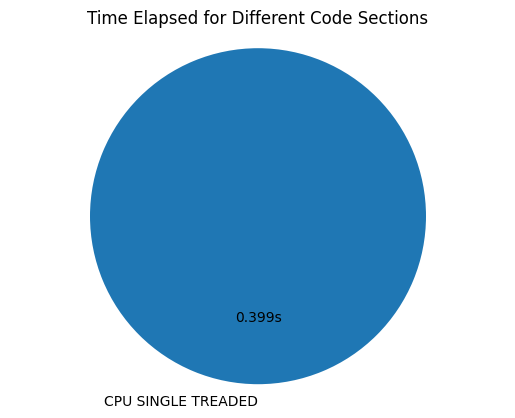

In [35]:
try:
    start_time=time.time()
    cleaned_text = pattern.sub(' ', raw_text)
    words = cleaned_text.split()

    word_counts = Counter()
    filtered_words = []

    for word in words:
        cleaned_word = pattern.sub('', word)
        if min_length <= len(cleaned_word) <= max_length and cleaned_word not in f_stopW:
            word_counts[cleaned_word] += 1
            filtered_words.append(cleaned_word)

    most_frequent_word, most_frequent_count =   max(word_counts.items(), key = lambda x: x[1])
    least_frequent_word, least_frequent_count = min(word_counts.items(), key = lambda x: x[1])

    total_filtered_words = sum(word_counts.values())
    print(time.time()-start_time)
    # Print the results
    print(f"Most frequent word: '{most_frequent_word}' with {most_frequent_count} occurrences")
    print(f"Least frequent word: '{least_frequent_word}' with {least_frequent_count} occurrences")
    print(f"Total number of filtered words: {total_filtered_words}")
    update_pie_chart("CPU SINGLE TREADED", (time.time()-start_time))
except Exception as e:
    print(f"Reading failed: {e}")

CPU MULTITREADING


Most frequent word: 'that' with 3100 occurrences
Least frequent word: 'january' with 1 occurrences
Total number of filtered words: 111233


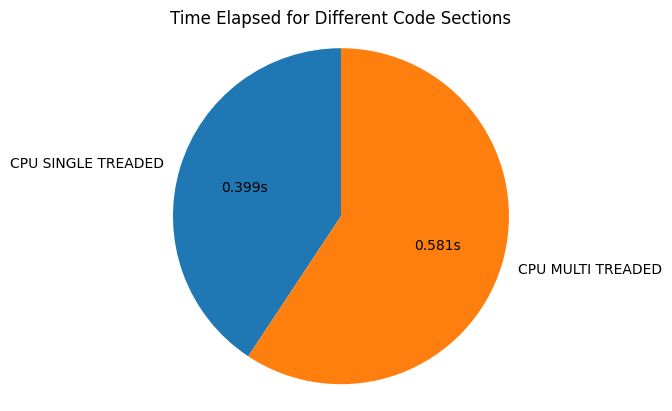

In [36]:
import multiprocessing

def process_chunk(chunk, stop_words, pattern, min_length, max_length):
    """
    Process a chunk of text: clean it, filter words, and count occurrences.
    """
    word_counts = Counter()
    filtered_words = []

    # Split the chunk into words and process each
    words = chunk.split()
    for word in words:
        cleaned_word = pattern.sub('', word.lower())  # Clean and lowercase each word
        if min_length <= len(cleaned_word) <= max_length and cleaned_word not in stop_words:
            word_counts[cleaned_word] += 1
            filtered_words.append(cleaned_word)

    return word_counts, filtered_words

def main():
    try:
        start_time=time.time()
        cleaned_text = pattern.sub(' ', raw_text)
        # Split the text into chunks for multiprocessing
        chunk_size = len(cleaned_text) // 2  # Divide text into equal-sized chunks
        chunks = [cleaned_text[i:i+chunk_size] for i in range(0, len(cleaned_text), chunk_size)]

        # Set up multiprocessing with 2 processes
        with multiprocessing.Pool(2) as pool:
            results = pool.starmap(
                process_chunk,
                [(chunk, f_stopW, pattern, min_length, max_length) for chunk in chunks]
            )

        # Combine results from all processes
        total_word_counts = Counter()
        all_filtered_words = []
        for word_counts, filtered_words in results:
            total_word_counts.update(word_counts)
            all_filtered_words.extend(filtered_words)

        # Get the most and least frequent words
        most_frequent_word, most_frequent_count = max(
            total_word_counts.items(), key=lambda x: x[1], default=(None, 0)
        )
        least_frequent_word, least_frequent_count = min(
            total_word_counts.items(), key=lambda x: x[1], default=(None, 0)
        )

        # Total number of words after filtering
        total_filtered_words = sum(total_word_counts.values())

        # Print the results
        print(f"Most frequent word: '{most_frequent_word}' with {most_frequent_count} occurrences")
        print(f"Least frequent word: '{least_frequent_word}' with {least_frequent_count} occurrences")
        print(f"Total number of filtered words: {total_filtered_words}")
        update_pie_chart("CPU MULTI TREADED", (time.time()-start_time))
    except Exception as e:
        print(f"Reading failed: {e}")

if __name__ == "__main__":
    main()


GPU

/usr/local/lib/python3.10/dist-packages/google/colab/_variable_inspector.py:27: UserWarning: module in out-of-thread context could not be cleaned up
  globals().clear()
/usr/local/lib/python3.10/dist-packages/google/colab/_variable_inspector.py:27: UserWarning: device_allocation in out-of-thread context could not be cleaned up
  globals().clear()


Filtered words and frequencies: {'project': 91, 'ebook': 10, 'moby': 89, 'dick': 89, 'whale': 1232, 'herman': 4, 'melville': 4, 'this': 1443, 'anyone': 6, 'anywhere': 16, 'cost': 4, 'with': 1770, 'almost': 197, 'copy': 19, 'give': 90, 'away': 186, 'under': 126, 'terms': 33, 'license': 18, 'included': 14, 'online': 4, 'title': 8, 'author': 9, 'last': 278, 'updated': 2, 'january': 1, '2009': 1, 'posting': 1, 'date': 5, 'december': 5, '2008': 1, '2701': 4, 'release': 1, 'june': 3, '2001': 2, 'language': 7, 'english': 50, 'start': 37, 'produced': 9, 'daniel': 4, 'lazarus': 7, 'jonesey': 2, 'original': 23, 'notes': 4, 'text': 6, 'etexts': 1, 'from': 1105, 'defunct': 2, 'eris': 1, 'virginia': 6, 'tech': 2, 'archives': 1, 'indebted': 2, 'adelaide': 1, 'library': 3, 'etext': 1, 'compared': 9, 'public': 15, 'domain': 9, 'hard': 84, 'chapters': 9, 'capital': 4, 'symbol': 12, 'british': 4, 'pound': 6, 'unit': 1, 'currency': 1, 'supplied': 12, 'late': 30, 'usher': 2, 'grammar': 2, 'school': 10, 'p

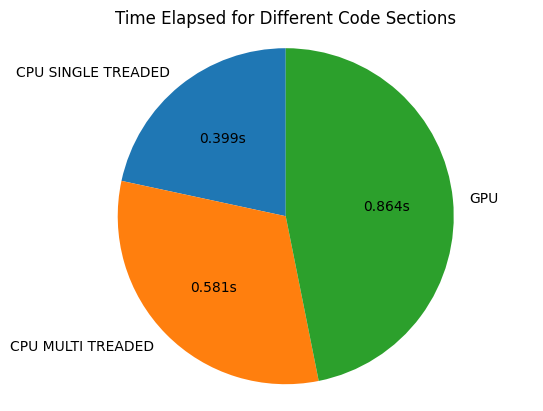

In [37]:
import numpy as np




start_time=time.time()

def preprocess_text(text, stop_words, min_word_length=2):
    # Inicializace

    words = re.findall(r'\b\w+\b', text.lower())
    word_to_id = {}
    id_to_word = {}
    text_ids = []
    stop_word_ids = set()
    current_id = 0
    data = np.array(list(pattern.sub('', text).encode('utf-8')), dtype=np.int32)


    byte_array_text = np.array(list(text.encode('utf-8')) + [0], dtype=np.uint8)
    for word in words + list(stop_words):
        if word not in word_to_id:
            word_to_id[word] = current_id
            id_to_word[current_id] = word
            current_id += 1


        if min_length <= len(word) <= max_length:
            text_ids.append(word_to_id[word])


        if word in stop_words:
            stop_word_ids.add(word_to_id[word])
    text_ids = np.array(text_ids, dtype=np.int32)
    stop_word_ids = np.array(list(stop_word_ids), dtype=np.int32)

    return text_ids, stop_word_ids, word_to_id, id_to_word

text_ids, stop_word_ids, word_to_id, id_to_word = preprocess_text(raw_text, f_stopW)


kernel_code = """
__global__ void filter_and_count(int *text_ids, int *stop_word_ids, int *word_freq, int text_len, int stop_len) {
    int idx = threadIdx.x + blockIdx.x * blockDim.x;
    if (idx < text_len) {
        int word_id = text_ids[idx];
        bool is_stop_word = false;

        // Check if the word is a stop word
        for (int i = 0; i < stop_len; i++) {
            if (word_id == stop_word_ids[i]) {
                is_stop_word = true;
                break;
            }
        }

        // If not a stop word, increment the frequency count
        if (!is_stop_word) {
            atomicAdd(&word_freq[word_id], 1);
        }
    }
}
"""

# Compile the CUDA kernel
mod = SourceModule(kernel_code)
filter_and_count = mod.get_function("filter_and_count")

# Allocate GPU memory
text_ids_gpu = cuda.mem_alloc(text_ids.nbytes)
stop_word_ids_gpu = cuda.mem_alloc(stop_word_ids.nbytes)
word_freq_gpu = cuda.mem_alloc(len(word_to_id) * np.int32(0).nbytes)

# Initialize word frequency array to zeros
word_freq = np.zeros(len(word_to_id), dtype=np.int32)
cuda.memcpy_htod(text_ids_gpu, text_ids)
cuda.memcpy_htod(stop_word_ids_gpu, stop_word_ids)
cuda.memcpy_htod(word_freq_gpu, word_freq)

# Launch the kernel
block_size = 256
grid_size = (len(text_ids) + block_size - 1) // block_size
filter_and_count(
    text_ids_gpu, stop_word_ids_gpu, word_freq_gpu,
    np.int32(len(text_ids)), np.int32(len(stop_word_ids)),
    block=(block_size, 1, 1), grid=(grid_size, 1)
)

cuda.memcpy_dtoh(word_freq, word_freq_gpu)
filtered_word_counts = {id_to_word[idx]: count for idx, count in enumerate(word_freq) if count > 0}

most_frequent_word = max(filtered_word_counts, key=filtered_word_counts.get)
most_frequent_count = filtered_word_counts[most_frequent_word]
least_frequent_word = min(filtered_word_counts, key=filtered_word_counts.get)
least_frequent_count = filtered_word_counts[least_frequent_word]

print(f"Filtered words and frequencies: {filtered_word_counts}")
print(f"Most frequent word: '{most_frequent_word}' with {most_frequent_count} occurrences")
print(f"Least frequent word: '{least_frequent_word}' with {least_frequent_count} occurrences")
print(f"Total number of unique filtered words: {len(filtered_word_counts)}")
update_pie_chart("GPU", (time.time()-start_time))


Most frequent word: 'that' with 3100 occurrences
Least frequent word: 'january' with 1 occurrences
Total number of unique filtered words: 11241


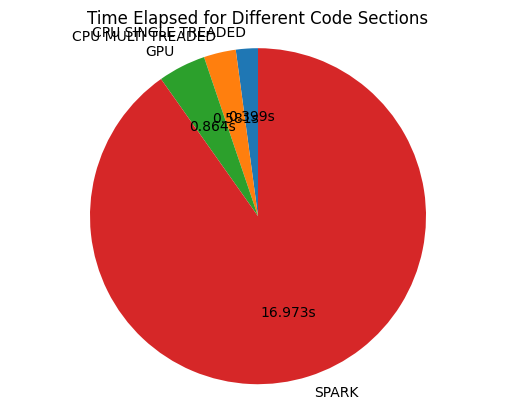

In [38]:
from pyspark.sql import SparkSession
start_time=time.time()
# Funkce pro extrakci slov pomocí re.findall a převod na malá písmena
def clean_text(text):
    return re.findall(r'\b[a-zA-Z]+\b', text.lower()) # Extrahuje slova a převádí na malá písmena

# Vytvoření SparkSession
spark = SparkSession.builder.appName("WordCount").getOrCreate()

# Čtení souboru a zpracování textu
lines = spark.read.text("data.txt").rdd.map(lambda r: r[0])

# Zpracování textu: extrakce slov, čištění, filtrování a počítání četností
word_counts = (
    lines.flatMap(clean_text)  # Extrahuje slova a převádí na malá písmena
         .filter(lambda word: 4 <= len(word) <= 8)  # Filtr na délku slov (4–8 znaků)
         .map(lambda word: (word, 1))  # Vytvoření dvojic (slovo, 1)
         .reduceByKey(lambda a, b: a + b)  # Sčítání četností jednotlivých slov
)

# Seřazení slov podle četnosti a výběr 10 nejčastějších
most_common_words = word_counts.sortBy(lambda x: x[1], ascending=True).collect()


most_frequent_word = most_common_words[-1][0]
most_frequent_count = most_common_words[-1][1]
least_frequent_word = most_common_words[0][0]
least_frequent_count = most_common_words[0][1]

# Output results
print(f"Most frequent word: '{most_frequent_word}' with {most_frequent_count} occurrences")
print(f"Least frequent word: '{least_frequent_word}' with {least_frequent_count} occurrences")
print(f"Total number of unique filtered words: {len(most_common_words)}")
update_pie_chart("SPARK", (time.time()-start_time))
# Ukončení SparkSession
spark.stop()
